<a href="https://www.kaggle.com/code/lalit7881/ai-dependency-student-burnout-eda?scriptVersionId=318670507" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings("ignore")
import plotly.express as px
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sridipbasu/ai-depndency-career-anxiety-and-student-burnout/ai_dependency_career_anxiety_students.csv
/kaggle/input/datasets/sridipbasu/ai-depndency-career-anxiety-and-student-burnout/feature_dictionary.csv
/kaggle/input/datasets/sridipbasu/ai-depndency-career-anxiety-and-student-burnout/dataset_metadata.json


## Loading dataset

In [2]:
file_path = "/kaggle/input/datasets/sridipbasu/ai-depndency-career-anxiety-and-student-burnout/ai_dependency_career_anxiety_students.csv"
df = pd.read_csv(file_path)


In [3]:
df.head()

,student_id,age,gender,degree_type,stream,year_of_study,college_tier,urban_or_rural,daily_ai_tool_usage_hrs,primary_ai_tools_used,...,daily_study_hours,self_learning_hours_per_week,skill_development_courses_taken,social_media_hrs_per_day,sleep_hours,stress_level,burnout_score,motivation_score,seeks_career_counseling,overall_career_readiness_score
0,STU_00001,25,Male,B.Tech/B.E.,Engineering (Non-CS),3,Tier 3,Rural,0.3,Perplexity,...,3.5,8.7,2,1.5,8.5,1,3,6,0.0,9.09
1,STU_00002,20,Female,B.Tech/B.E.,Engineering (Non-CS),4,Tier 3,Urban,1.9,ChatGPT,...,2.4,8.2,3,4.2,8.3,4,5,3,0.0,6.03
2,STU_00003,25,Female,MBA,CS/IT,1,Tier 3,Urban,3.6,Gemini,...,2.3,16.4,1,2.3,7.0,5,9,3,1.0,6.68
3,STU_00004,23,Male,B.Tech/B.E.,CS/IT,1,Tier 1,Urban,4.1,GitHub Copilot,...,7.7,15.0,3,2.6,7.2,6,6,6,0.0,7.71
4,STU_00005,22,Female,MBA,CS/IT,1,Tier 1,Urban,3.4,ChatGPT,...,2.4,1.1,2,1.9,8.0,3,5,4,0.0,4.64


In [4]:
df.tail()

,student_id,age,gender,degree_type,stream,year_of_study,college_tier,urban_or_rural,daily_ai_tool_usage_hrs,primary_ai_tools_used,...,daily_study_hours,self_learning_hours_per_week,skill_development_courses_taken,social_media_hrs_per_day,sleep_hours,stress_level,burnout_score,motivation_score,seeks_career_counseling,overall_career_readiness_score
14995,STU_14996,21,Female,B.Sc/B.A/B.Com,CS/IT,1,Tier 3,Urban,2.8,ChatGPT,...,0.0,6.2,2,0.2,9.6,4,6,2,0.0,7.02
14996,STU_14997,22,Male,B.Tech/B.E.,Commerce/Management,4,Tier 1,Urban,3.6,ChatGPT,...,6.1,11.7,3,2.9,5.8,5,3,9,1.0,7.31
14997,STU_14998,22,Male,B.Tech/B.E.,CS/IT,2,Tier 1,Rural,1.7,Gemini,...,6.3,17.2,5,0.6,7.4,3,1,9,0.0,8.65
14998,STU_14999,22,Female,MBA,CS/IT,2,Tier 2,Urban,0.0,NaN,...,0.8,0.0,1,2.0,9.1,5,6,2,0.0,4.97
14999,STU_15000,23,Male,M.Tech/M.Sc,Engineering (Non-CS),2,Tier 3,Rural,2.1,ChatGPT,...,2.9,1.0,3,3.9,7.4,7,7,4,0.0,5.28


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   student_id                       15000 non-null  object 
 1   age                              15000 non-null  int64  
 2   gender                           15000 non-null  object 
 3   degree_type                      15000 non-null  object 
 4   stream                           15000 non-null  object 
 5   year_of_study                    15000 non-null  int64  
 6   college_tier                     15000 non-null  object 
 7   urban_or_rural                   15000 non-null  object 
 8   daily_ai_tool_usage_hrs          15000 non-null  float64
 9   primary_ai_tools_used            11785 non-null  object 
 10  uses_ai_for_assignments          15000 non-null  object 
 11  ai_replaces_own_thinking_score   15000 non-null  int64  
 12  ai_dependency_scor

In [6]:
df.describe()

,age,year_of_study,daily_ai_tool_usage_hrs,ai_replaces_own_thinking_score,ai_dependency_score,placement_anxiety_score,fear_of_job_loss_to_ai,career_clarity_score,internship_experience,weekly_job_application_count,...,daily_study_hours,self_learning_hours_per_week,skill_development_courses_taken,social_media_hrs_per_day,sleep_hours,stress_level,burnout_score,motivation_score,seeks_career_counseling,overall_career_readiness_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,...,15000.000000,14767.000000,15000.0000,14790.000000,14797.000000,15000.000000,15000.000000,15000.000000,14780.000000,15000.000000
mean,21.384533,2.100067,2.013893,2.987733,4.539133,5.913933,3.551200,5.025333,1.718333,10.636133,...,2.730660,6.304612,2.0326,3.006437,6.993364,4.771133,5.472600,4.319733,0.285792,5.998019
std,2.005626,0.987650,1.735977,1.311932,2.315115,2.548207,1.180397,2.200806,1.069583,6.402411,...,1.801026,5.553880,1.8095,1.649033,1.004809,1.778210,2.068317,2.151266,0.451806,1.593982
min,18.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.0000,0.000000,4.000000,1.000000,1.000000,1.000000,0.000000,1.000000
25%,20.000000,1.000000,0.400000,2.000000,3.000000,4.000000,3.000000,3.000000,1.000000,6.000000,...,1.300000,1.000000,1.0000,1.800000,6.300000,4.000000,4.000000,3.000000,0.000000,4.900000
50%,21.000000,2.000000,1.800000,3.000000,4.000000,6.000000,4.000000,5.000000,2.000000,10.000000,...,2.600000,5.500000,2.0000,3.000000,7.000000,5.000000,5.000000,4.000000,0.000000,6.000000
75%,22.000000,3.000000,3.200000,4.000000,6.000000,8.000000,5.000000,6.000000,2.000000,15.000000,...,4.000000,10.100000,3.0000,4.100000,7.700000,6.000000,7.000000,6.000000,1.000000,7.120000
max,28.000000,4.000000,8.000000,5.000000,10.000000,10.000000,5.000000,10.000000,4.000000,35.000000,...,10.300000,31.000000,10.0000,8.000000,10.000000,10.000000,10.000000,10.000000,1.000000,10.000000


In [7]:
df.isnull().sum()

student_id                            0
age                                   0
gender                                0
degree_type                           0
stream                                0
year_of_study                         0
college_tier                          0
urban_or_rural                        0
daily_ai_tool_usage_hrs               0
primary_ai_tools_used              3215
uses_ai_for_assignments               0
ai_replaces_own_thinking_score        0
ai_dependency_score                   0
placement_anxiety_score               0
fear_of_job_loss_to_ai                0
career_clarity_score                  0
internship_experience                 0
weekly_job_application_count          0
resume_confidence_score               0
interview_anxiety_score               0
daily_study_hours                     0
self_learning_hours_per_week        233
skill_development_courses_taken       0
social_media_hrs_per_day            210
sleep_hours                         203


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns

Index(['student_id', 'age', 'gender', 'degree_type', 'stream', 'year_of_study',
       'college_tier', 'urban_or_rural', 'daily_ai_tool_usage_hrs',
       'primary_ai_tools_used', 'uses_ai_for_assignments',
       'ai_replaces_own_thinking_score', 'ai_dependency_score',
       'placement_anxiety_score', 'fear_of_job_loss_to_ai',
       'career_clarity_score', 'internship_experience',
       'weekly_job_application_count', 'resume_confidence_score',
       'interview_anxiety_score', 'daily_study_hours',
       'self_learning_hours_per_week', 'skill_development_courses_taken',
       'social_media_hrs_per_day', 'sleep_hours', 'stress_level',
       'burnout_score', 'motivation_score', 'seeks_career_counseling',
       'overall_career_readiness_score'],
      dtype='object')

In [10]:
df.dtypes

student_id                          object
age                                  int64
gender                              object
degree_type                         object
stream                              object
year_of_study                        int64
college_tier                        object
urban_or_rural                      object
daily_ai_tool_usage_hrs            float64
primary_ai_tools_used               object
uses_ai_for_assignments             object
ai_replaces_own_thinking_score       int64
ai_dependency_score                  int64
placement_anxiety_score              int64
fear_of_job_loss_to_ai               int64
career_clarity_score                 int64
internship_experience                int64
weekly_job_application_count         int64
resume_confidence_score              int64
interview_anxiety_score              int64
daily_study_hours                  float64
self_learning_hours_per_week       float64
skill_development_courses_taken      int64
social_medi

In [11]:
df.shape

(15000, 30)

In [12]:
df.nunique()

student_id                         15000
age                                   11
gender                                 3
degree_type                            4
stream                                 4
year_of_study                          4
college_tier                           3
urban_or_rural                         2
daily_ai_tool_usage_hrs               81
primary_ai_tools_used                  5
uses_ai_for_assignments                5
ai_replaces_own_thinking_score         5
ai_dependency_score                   10
placement_anxiety_score               10
fear_of_job_loss_to_ai                 5
career_clarity_score                  10
internship_experience                  5
weekly_job_application_count          36
resume_confidence_score                5
interview_anxiety_score               10
daily_study_hours                     95
self_learning_hours_per_week         265
skill_development_courses_taken       11
social_media_hrs_per_day              81
sleep_hours     

In [13]:
df.isnull()

,student_id,age,gender,degree_type,stream,year_of_study,college_tier,urban_or_rural,daily_ai_tool_usage_hrs,primary_ai_tools_used,...,daily_study_hours,self_learning_hours_per_week,skill_development_courses_taken,social_media_hrs_per_day,sleep_hours,stress_level,burnout_score,motivation_score,seeks_career_counseling,overall_career_readiness_score
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
14996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
14997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
14998,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


## EDA

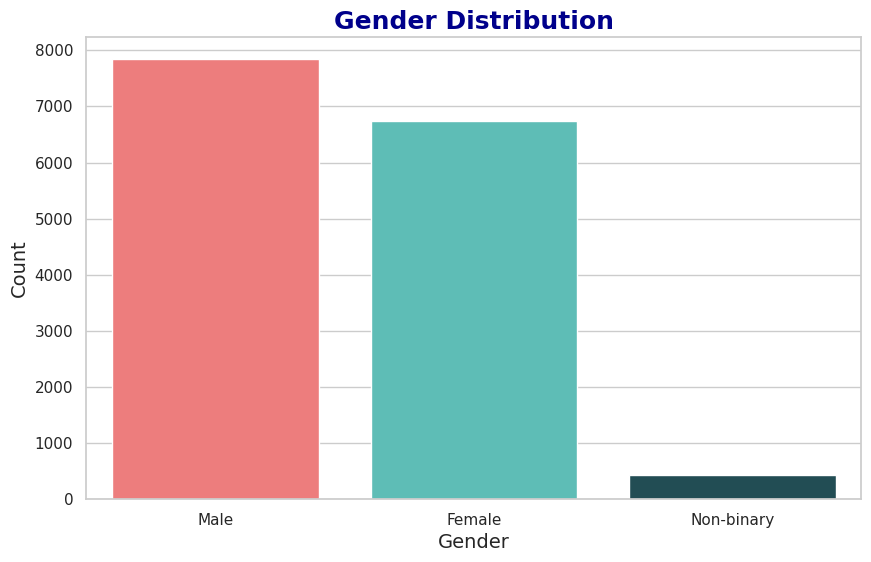

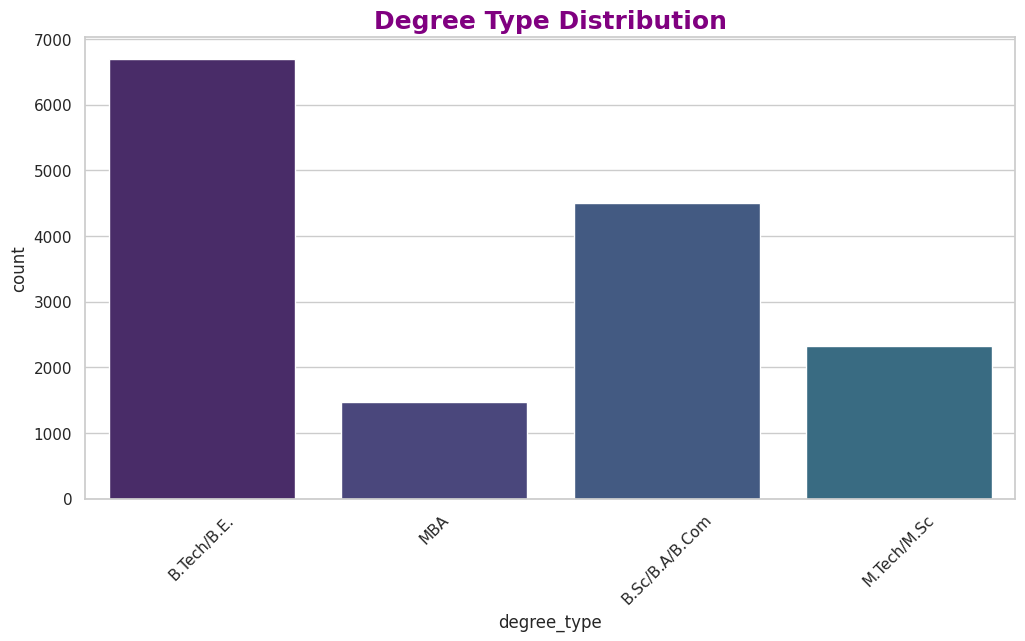

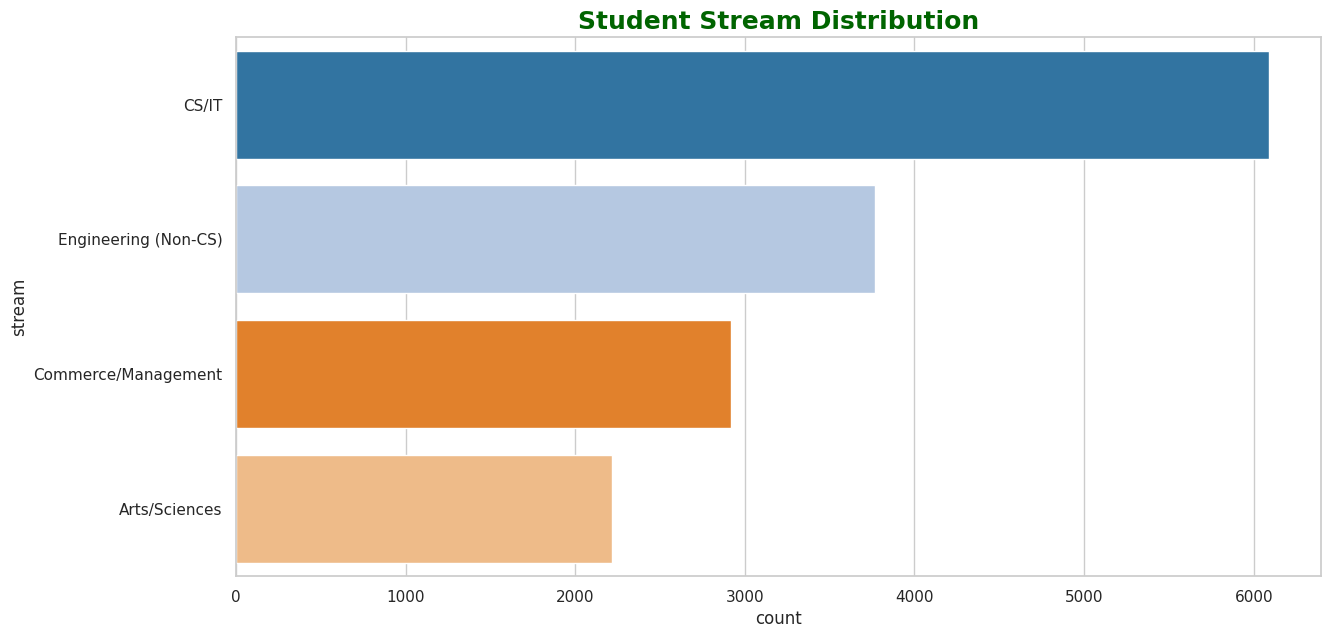

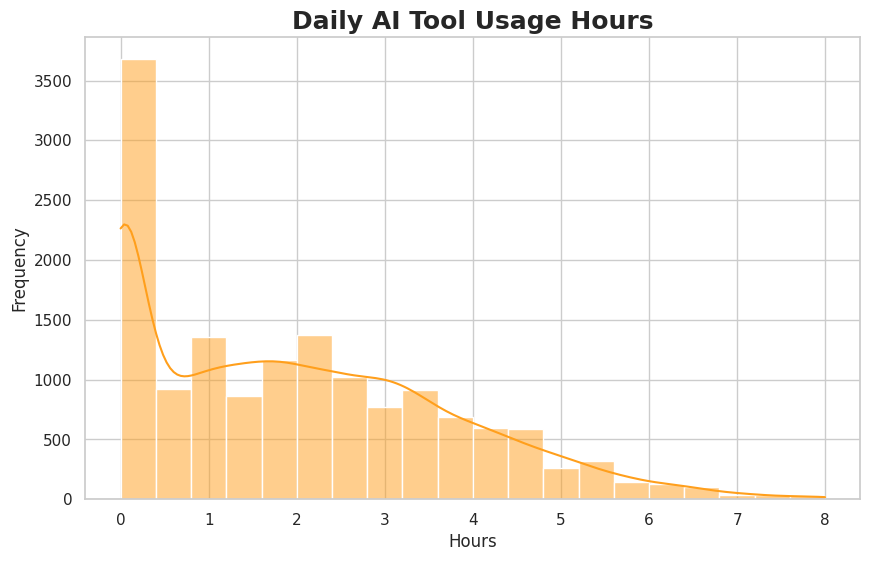

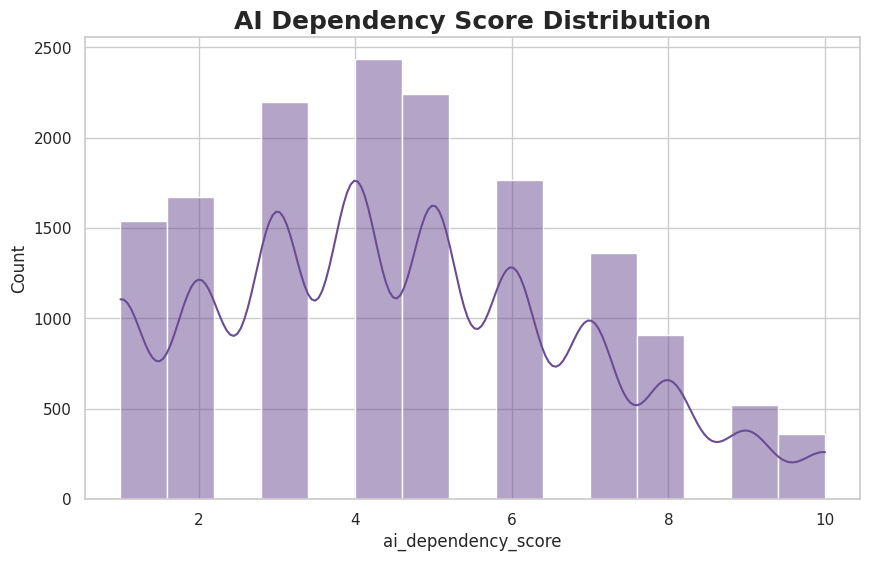

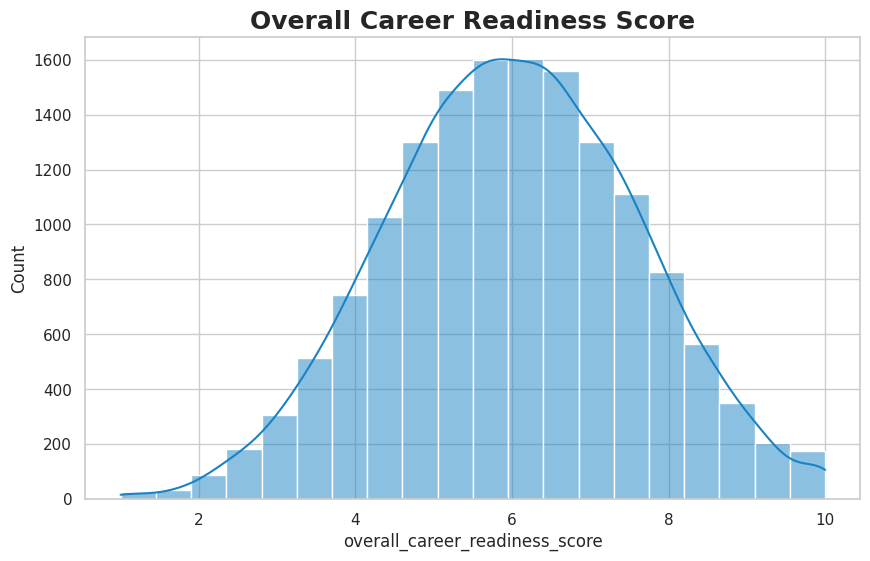

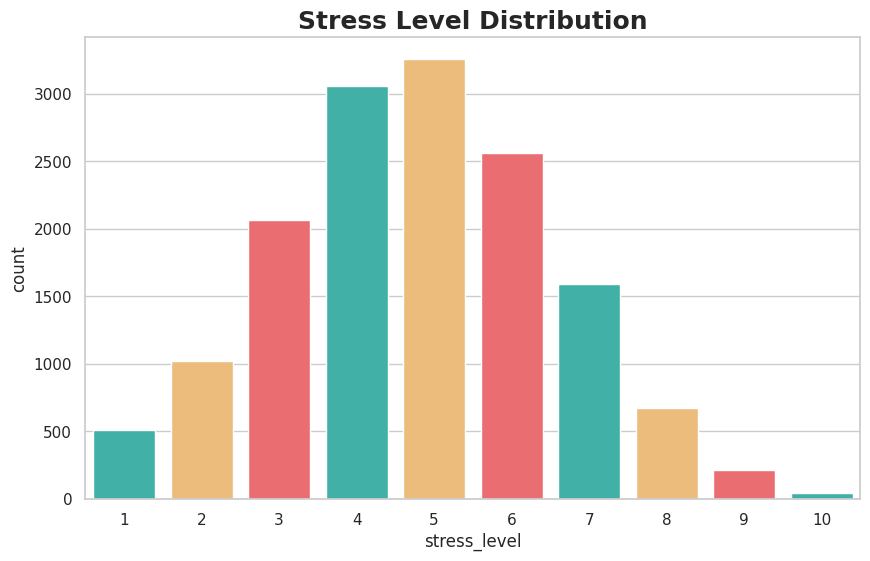

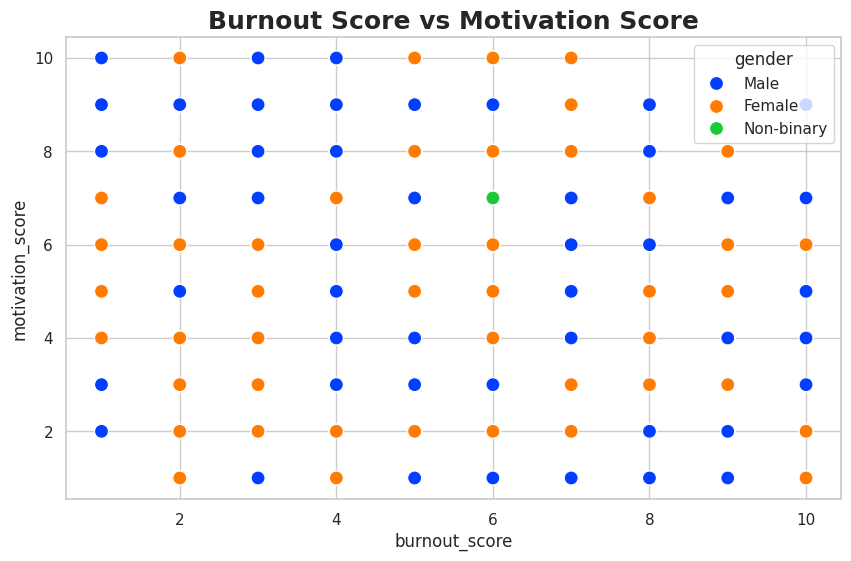

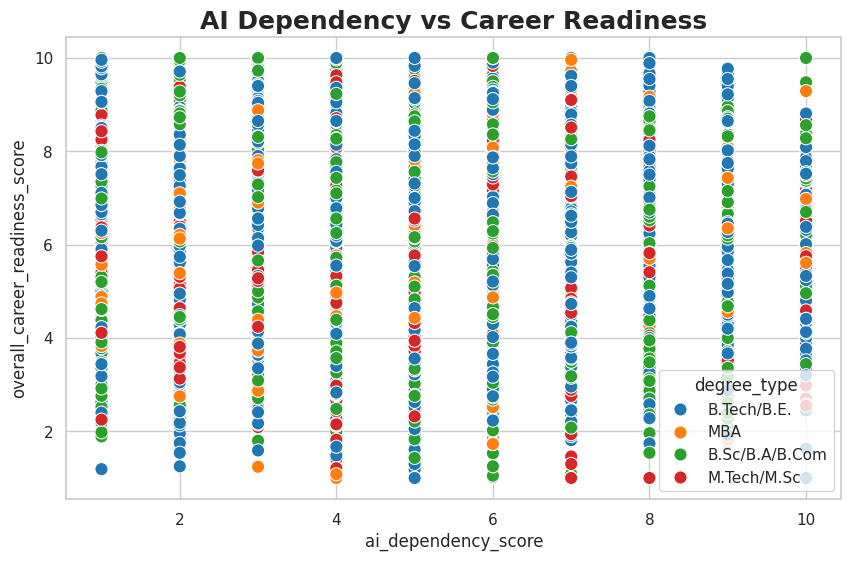

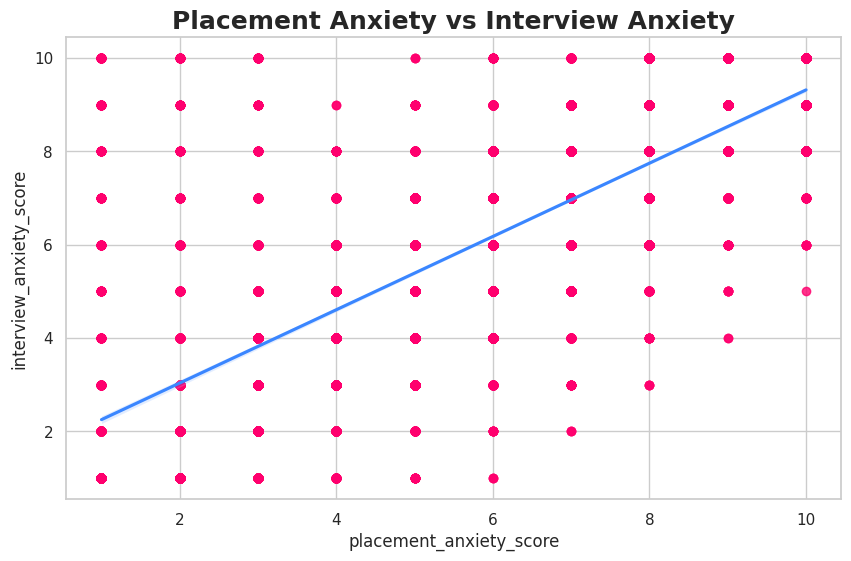

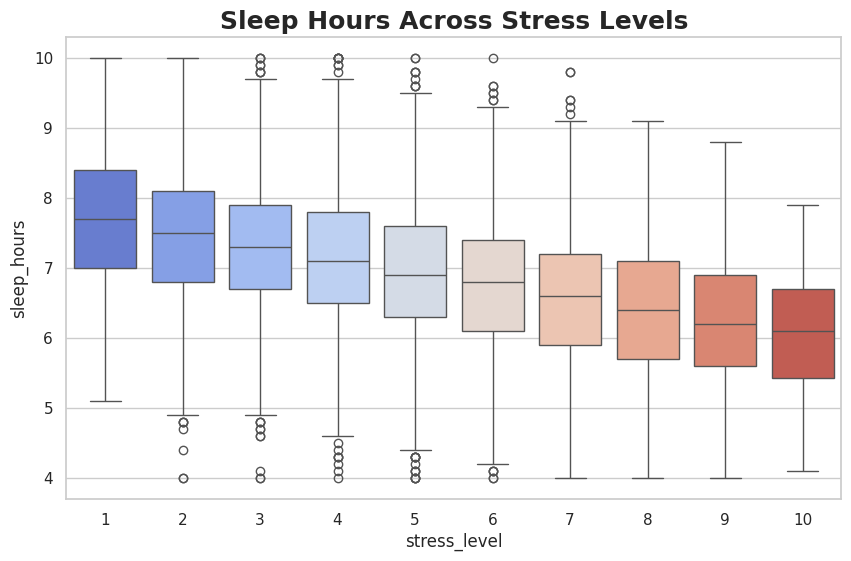

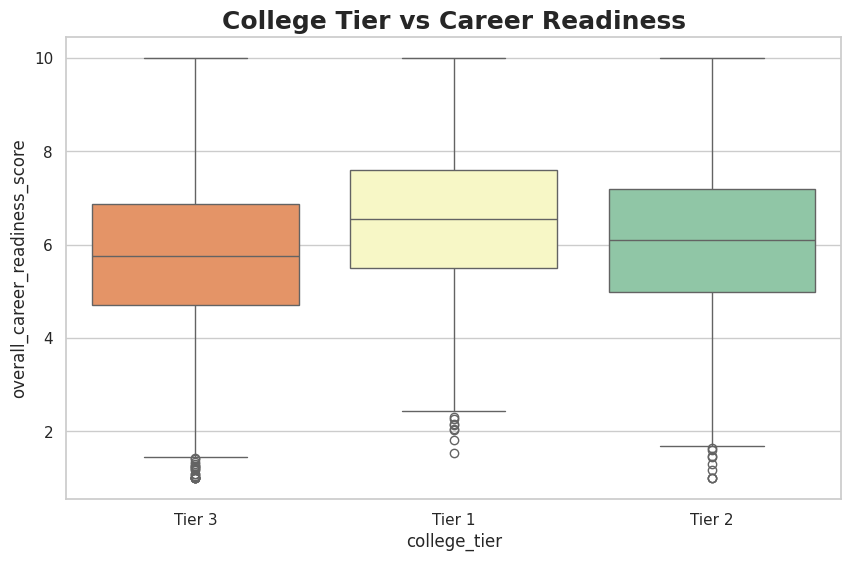

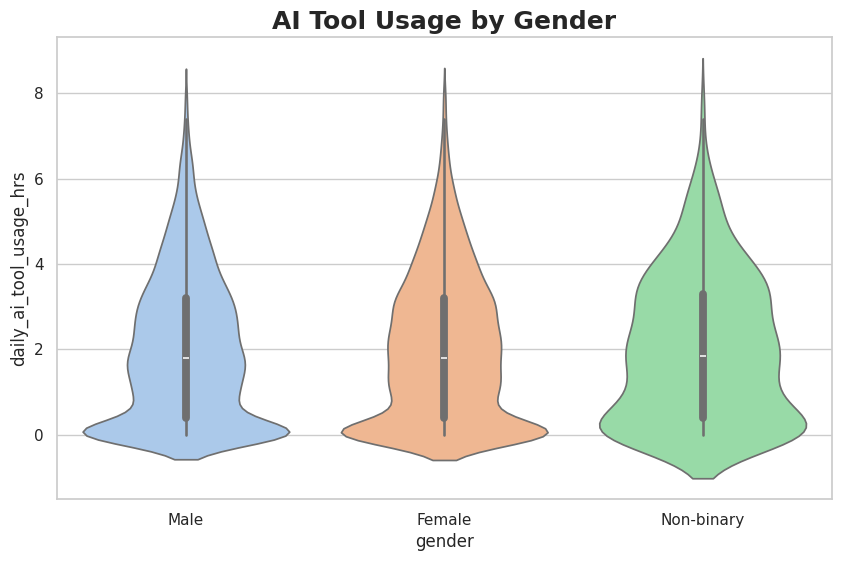

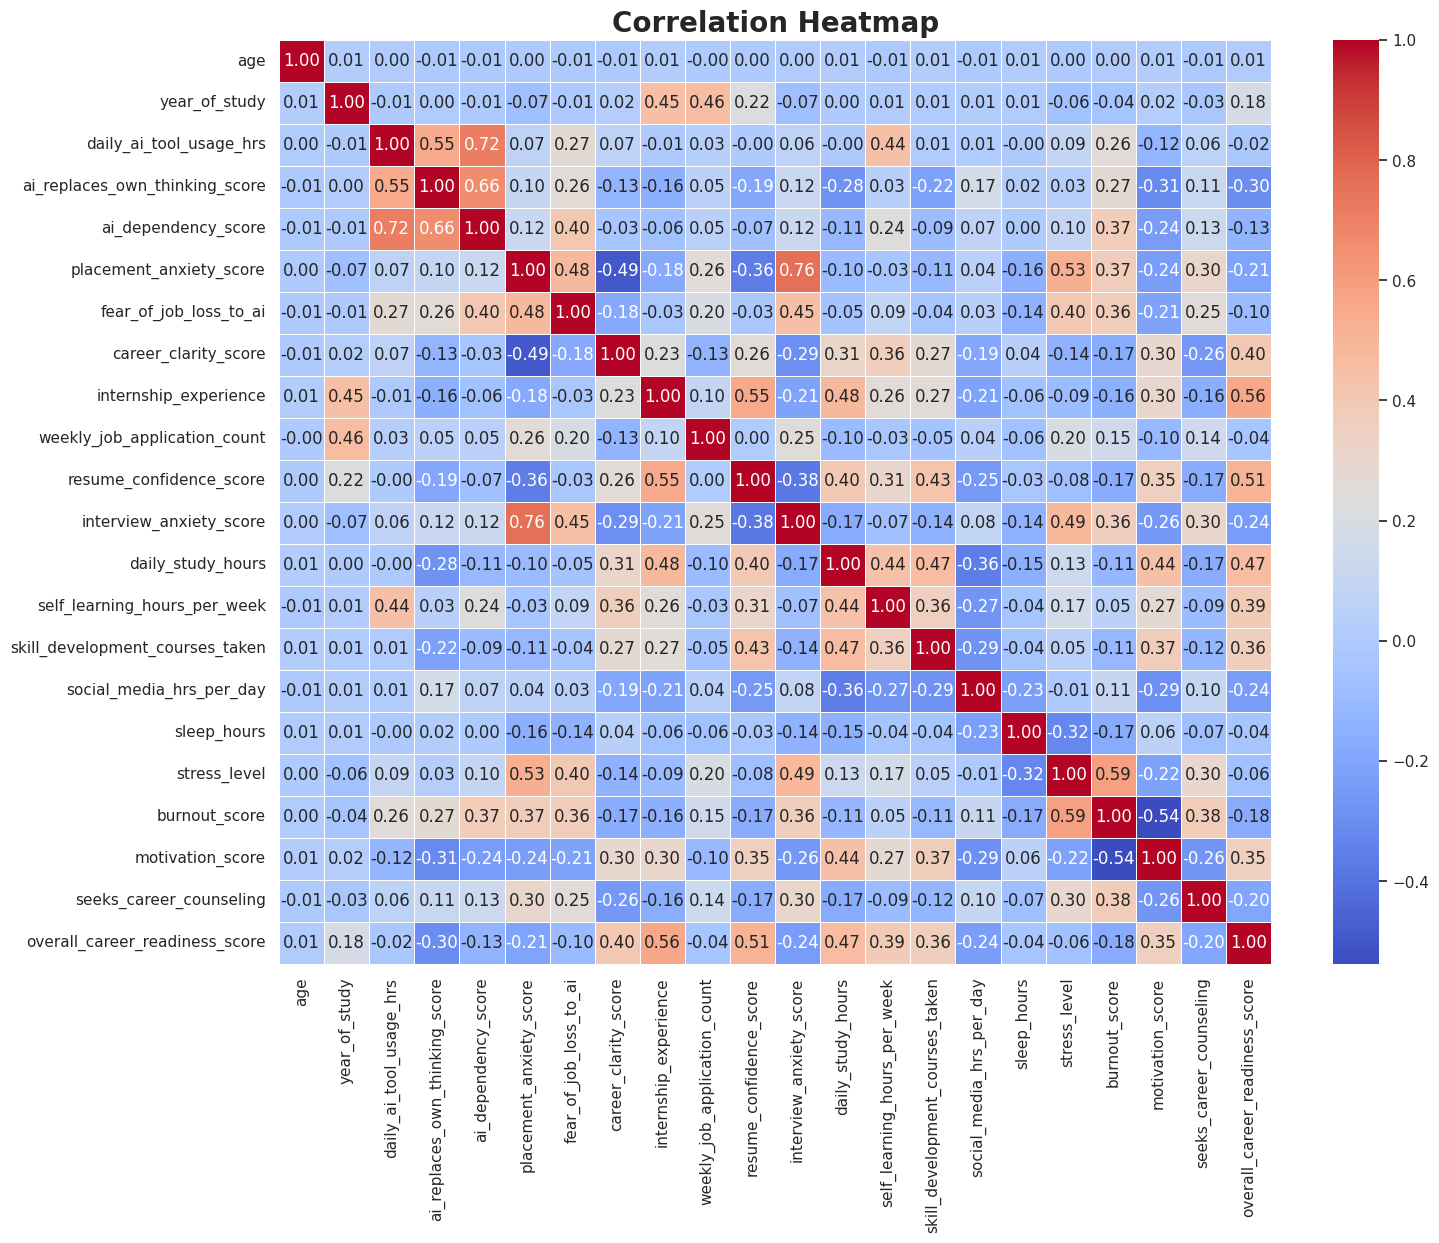

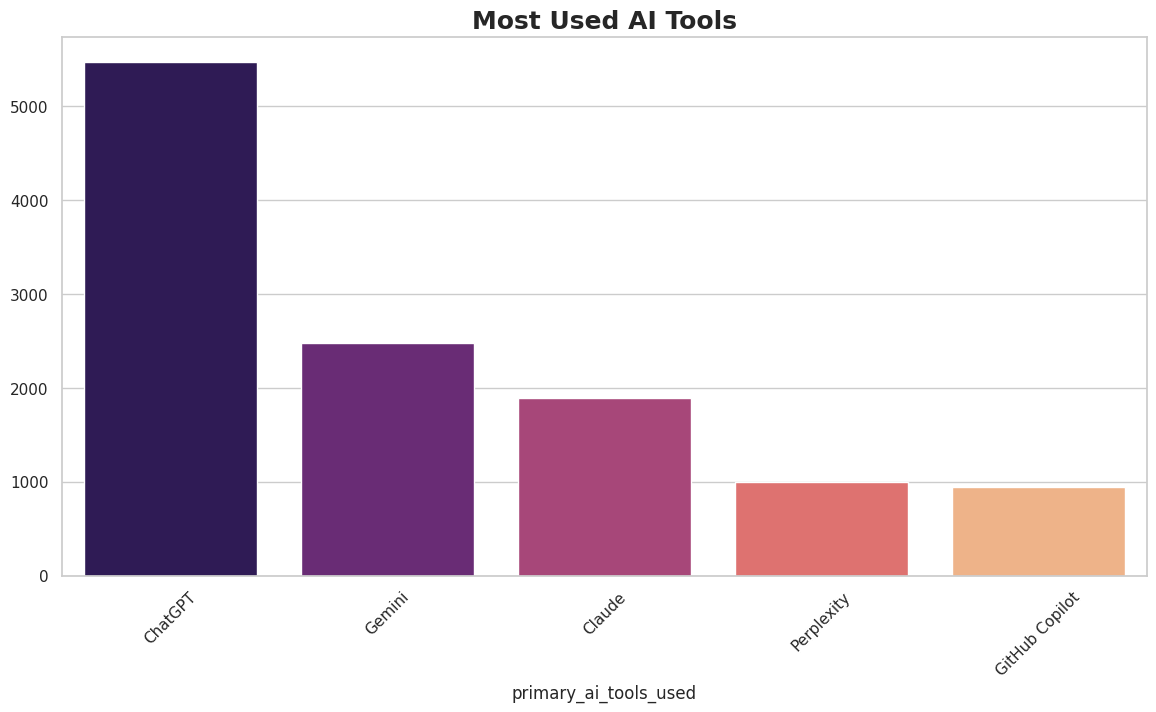

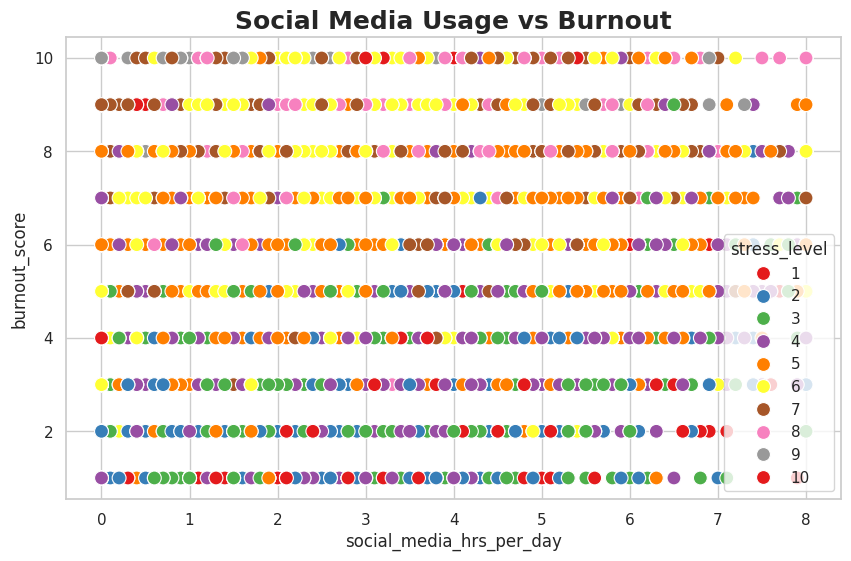

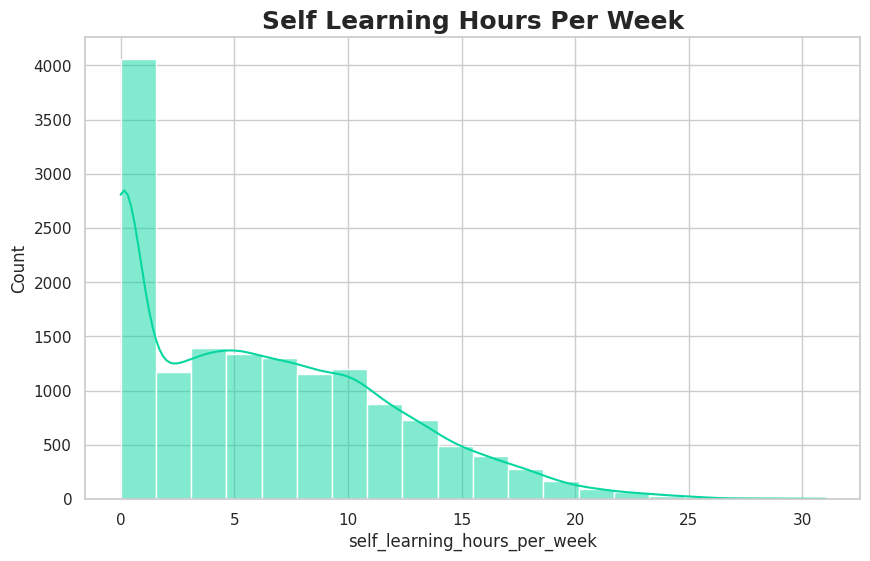

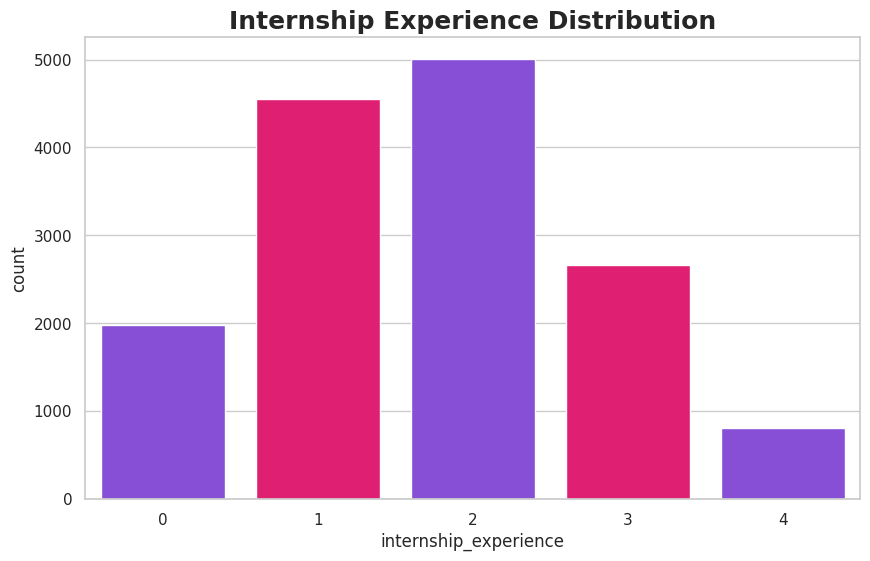

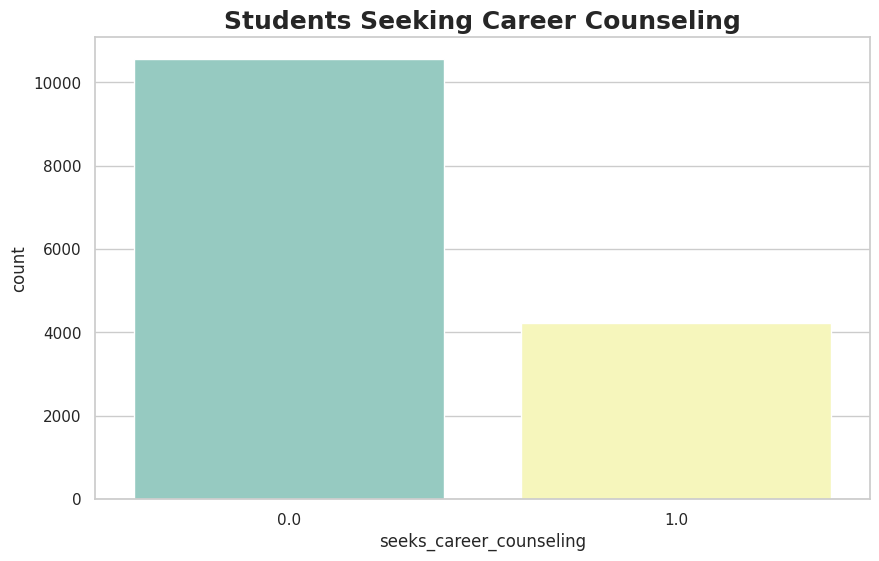

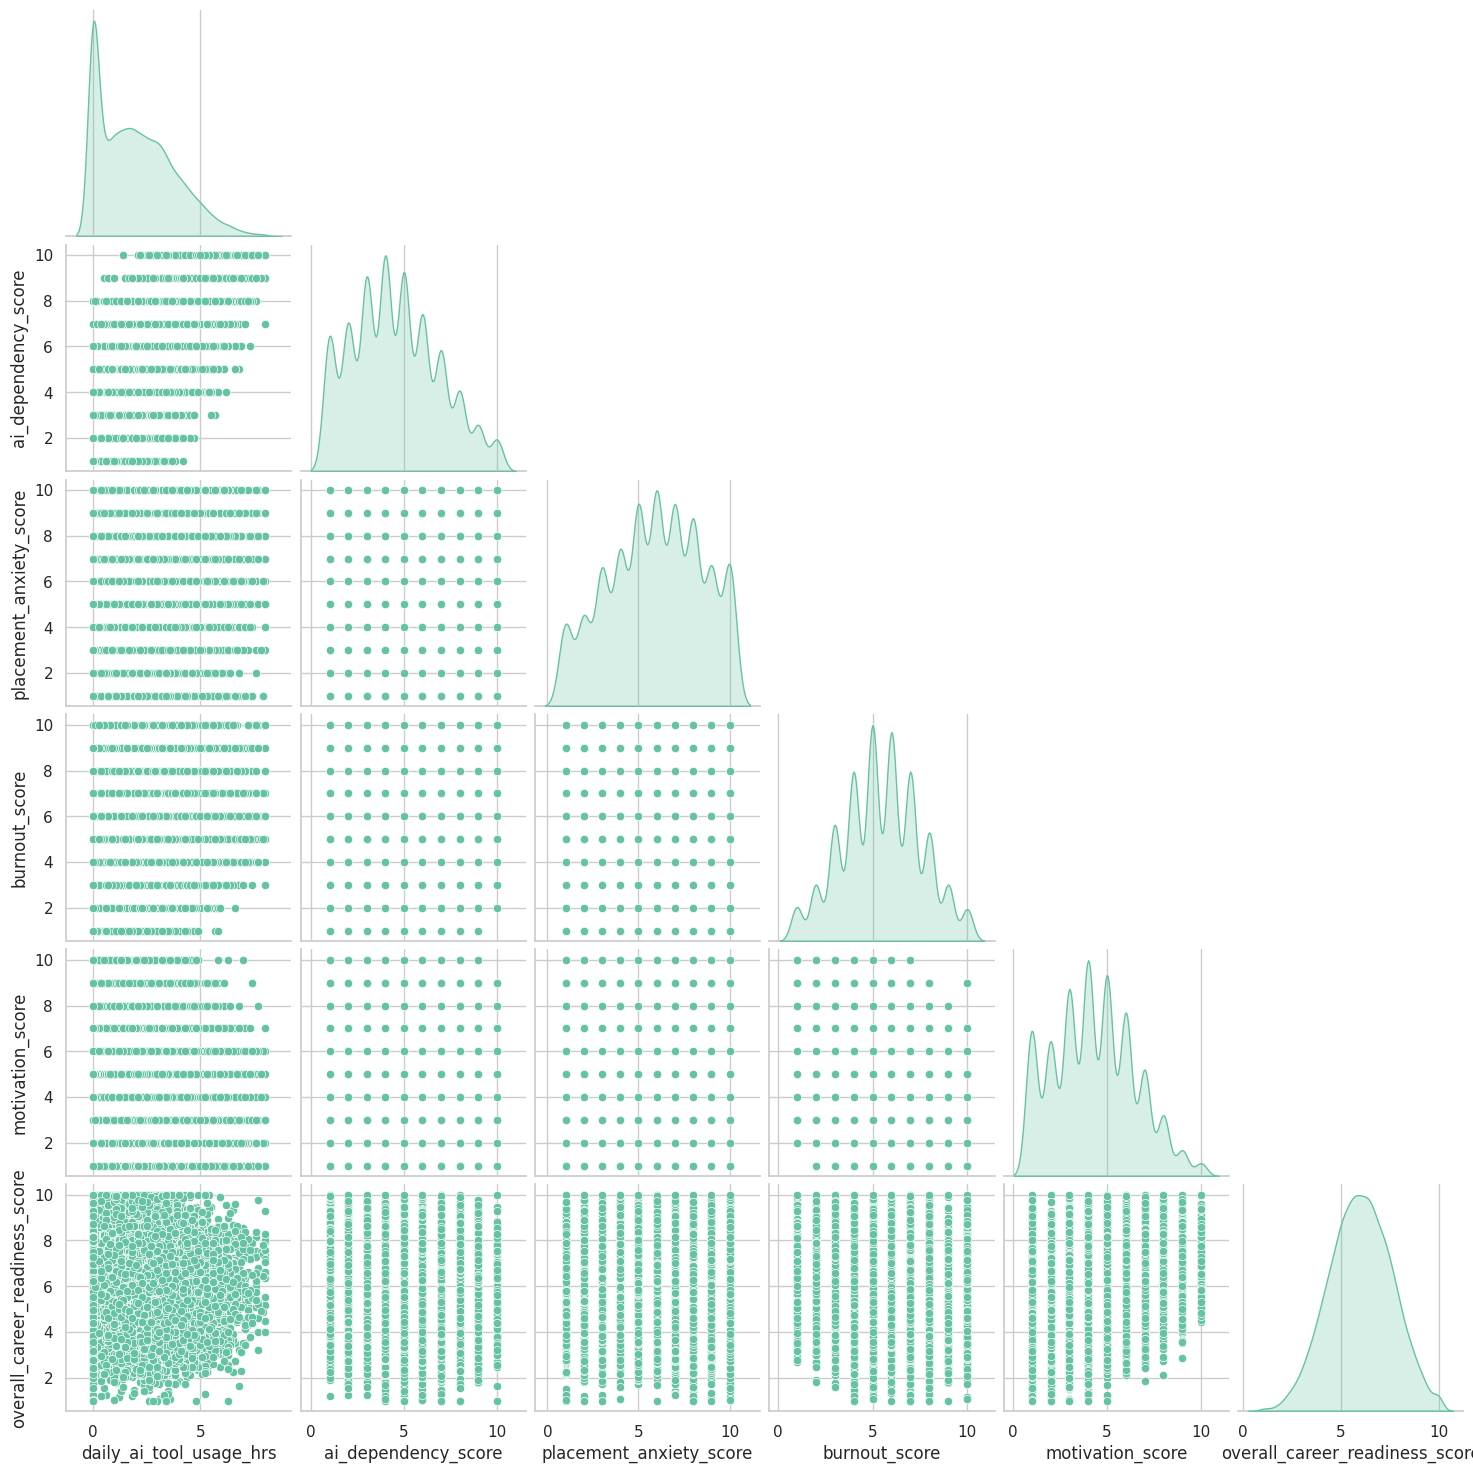

In [14]:
plt.style.use("ggplot")

sns.set(
    style="whitegrid",
    palette="Set2"
)

# ============================================
# CREATE FIGURE SIZE FUNCTION
# ============================================

def set_size(width=10, height=6):
    plt.figure(figsize=(width, height))

# ============================================
# 1. GENDER DISTRIBUTION
# ============================================

set_size()

gender_colors = ["#ff6b6b", "#4ecdc4", "#1a535c"]

sns.countplot(
    data=df,
    x="gender",
    palette=gender_colors
)

plt.title(
    "Gender Distribution",
    fontsize=18,
    fontweight="bold",
    color="darkblue"
)

plt.xlabel("Gender", fontsize=14)
plt.ylabel("Count", fontsize=14)

plt.show()

# ============================================
# 2. DEGREE TYPE DISTRIBUTION
# ============================================

set_size(12, 6)

degree_colors = sns.color_palette("viridis", 10)

sns.countplot(
    data=df,
    x="degree_type",
    palette=degree_colors
)

plt.title(
    "Degree Type Distribution",
    fontsize=18,
    fontweight="bold",
    color="purple"
)

plt.xticks(rotation=45)

plt.show()

# ============================================
# 3. STREAM DISTRIBUTION
# ============================================

set_size(14, 7)

stream_colors = sns.color_palette("tab20", 20)

sns.countplot(
    data=df,
    y="stream",
    palette=stream_colors,
    order=df["stream"].value_counts().index
)

plt.title(
    "Student Stream Distribution",
    fontsize=18,
    fontweight="bold",
    color="darkgreen"
)

plt.show()

# ============================================
# 4. DAILY AI TOOL USAGE DISTRIBUTION
# ============================================

set_size()

sns.histplot(
    df["daily_ai_tool_usage_hrs"],
    bins=20,
    kde=True,
    color="#ff9f1c"
)

plt.title(
    "Daily AI Tool Usage Hours",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Hours")
plt.ylabel("Frequency")

plt.show()

# ============================================
# 5. AI DEPENDENCY SCORE DISTRIBUTION
# ============================================

set_size()

sns.histplot(
    df["ai_dependency_score"],
    bins=15,
    kde=True,
    color="#6a4c93"
)

plt.title(
    "AI Dependency Score Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.show()

# ============================================
# 6. CAREER READINESS SCORE DISTRIBUTION
# ============================================

set_size()

sns.histplot(
    df["overall_career_readiness_score"],
    bins=20,
    kde=True,
    color="#1982c4"
)

plt.title(
    "Overall Career Readiness Score",
    fontsize=18,
    fontweight="bold"
)

plt.show()

# ============================================
# 7. STRESS LEVEL COUNT
# ============================================

set_size()

stress_colors = ["#2ec4b6", "#ffbf69", "#ff595e"]

sns.countplot(
    data=df,
    x="stress_level",
    palette=stress_colors
)

plt.title(
    "Stress Level Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.show()

# ============================================
# 8. BURNOUT VS MOTIVATION
# ============================================

set_size()

sns.scatterplot(
    data=df,
    x="burnout_score",
    y="motivation_score",
    hue="gender",
    palette="bright",
    s=100
)

plt.title(
    "Burnout Score vs Motivation Score",
    fontsize=18,
    fontweight="bold"
)

plt.show()

# ============================================
# 9. AI DEPENDENCY VS CAREER READINESS
# ============================================

set_size()

sns.scatterplot(
    data=df,
    x="ai_dependency_score",
    y="overall_career_readiness_score",
    hue="degree_type",
    palette="tab10",
    s=90
)

plt.title(
    "AI Dependency vs Career Readiness",
    fontsize=18,
    fontweight="bold"
)

plt.show()

# ============================================
# 10. PLACEMENT ANXIETY VS INTERVIEW ANXIETY
# ============================================

set_size()

sns.regplot(
    data=df,
    x="placement_anxiety_score",
    y="interview_anxiety_score",
    scatter_kws={"color": "#ff006e"},
    line_kws={"color": "#3a86ff"}
)

plt.title(
    "Placement Anxiety vs Interview Anxiety",
    fontsize=18,
    fontweight="bold"
)

plt.show()

# ============================================
# 11. SLEEP HOURS VS STRESS LEVEL
# ============================================

set_size()

sns.boxplot(
    data=df,
    x="stress_level",
    y="sleep_hours",
    palette="coolwarm"
)

plt.title(
    "Sleep Hours Across Stress Levels",
    fontsize=18,
    fontweight="bold"
)

plt.show()

# ============================================
# 12. COLLEGE TIER VS CAREER READINESS
# ============================================

set_size()

sns.boxplot(
    data=df,
    x="college_tier",
    y="overall_career_readiness_score",
    palette="Spectral"
)

plt.title(
    "College Tier vs Career Readiness",
    fontsize=18,
    fontweight="bold"
)

plt.show()

# ============================================
# 13. AI TOOL USAGE BY GENDER
# ============================================

set_size()

sns.violinplot(
    data=df,
    x="gender",
    y="daily_ai_tool_usage_hrs",
    palette="pastel"
)

plt.title(
    "AI Tool Usage by Gender",
    fontsize=18,
    fontweight="bold"
)

plt.show()

# ============================================
# 14. CORRELATION HEATMAP
# ============================================

set_size(16, 12)

numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title(
    "Correlation Heatmap",
    fontsize=20,
    fontweight="bold"
)

plt.show()

# ============================================
# 15. TOP AI TOOLS USED
# ============================================

set_size(14, 7)

tool_counts = df["primary_ai_tools_used"].value_counts()

sns.barplot(
    x=tool_counts.index,
    y=tool_counts.values,
    palette="magma"
)

plt.title(
    "Most Used AI Tools",
    fontsize=18,
    fontweight="bold"
)

plt.xticks(rotation=45)

plt.show()

# ============================================
# 16. SOCIAL MEDIA HOURS VS BURNOUT
# ============================================

set_size()

sns.scatterplot(
    data=df,
    x="social_media_hrs_per_day",
    y="burnout_score",
    hue="stress_level",
    palette="Set1",
    s=100
)

plt.title(
    "Social Media Usage vs Burnout",
    fontsize=18,
    fontweight="bold"
)

plt.show()

# ============================================
# 17. SELF LEARNING HOURS DISTRIBUTION
# ============================================

set_size()

sns.histplot(
    df["self_learning_hours_per_week"],
    bins=20,
    kde=True,
    color="#06d6a0"
)

plt.title(
    "Self Learning Hours Per Week",
    fontsize=18,
    fontweight="bold"
)

plt.show()

# ============================================
# 18. INTERNSHIP EXPERIENCE ANALYSIS
# ============================================

set_size()

intern_colors = ["#8338ec", "#ff006e"]

sns.countplot(
    data=df,
    x="internship_experience",
    palette=intern_colors
)

plt.title(
    "Internship Experience Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.show()

# ============================================
# 19. CAREER COUNSELING ANALYSIS
# ============================================

set_size()

sns.countplot(
    data=df,
    x="seeks_career_counseling",
    palette="Set3"
)

plt.title(
    "Students Seeking Career Counseling",
    fontsize=18,
    fontweight="bold"
)

plt.show()

# ============================================
# 20. PAIRPLOT
# ============================================

selected_columns = [
    "daily_ai_tool_usage_hrs",
    "ai_dependency_score",
    "placement_anxiety_score",
    "burnout_score",
    "motivation_score",
    "overall_career_readiness_score"
]

sns.pairplot(
    df[selected_columns],
    corner=True,
    diag_kind="kde"
)

plt.show()

# ============================================
# INTERACTIVE PLOTLY VISUALIZATION
# ============================================

fig = px.scatter(
    df,
    x="ai_dependency_score",
    y="overall_career_readiness_score",
    color="stress_level",
    size="daily_ai_tool_usage_hrs",
    hover_data=["degree_type", "stream"],
    title="Interactive AI Dependency vs Career Readiness"
)

fig.show()



## Feature Engineering

In [15]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

# Split
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)


================ CATEGORICAL COLUMNS ================

Index(['gender', 'degree_type', 'stream', 'college_tier', 'urban_or_rural',
       'primary_ai_tools_used', 'uses_ai_for_assignments'],
      dtype='object')

================ NaN CHECK AFTER IMPUTATION ================

Train NaN Count: 0
Test NaN Count : 0

================ TRAIN TEST SHAPES ================

X_train : (12000, 28)
X_test  : (3000, 28)
y_train : (12000,)
y_test  : (3000,)

MODEL : Logistic Regression

Accuracy  : 0.5933
Precision : 0.5887
Recall    : 0.5933
F1 Score  : 0.5907

================ CLASSIFICATION REPORT ================

              precision    recall  f1-score   support

           0       0.67      0.69      0.68      1002
           1       0.45      0.42      0.43      1003
           2       0.65      0.67      0.66       995

    accuracy                           0.59      3000
   macro avg       0.59      0.59      0.59      3000
weighted avg       0.59      0.59      0.59      3000



<Figure size 1200x800 with 0 Axes>

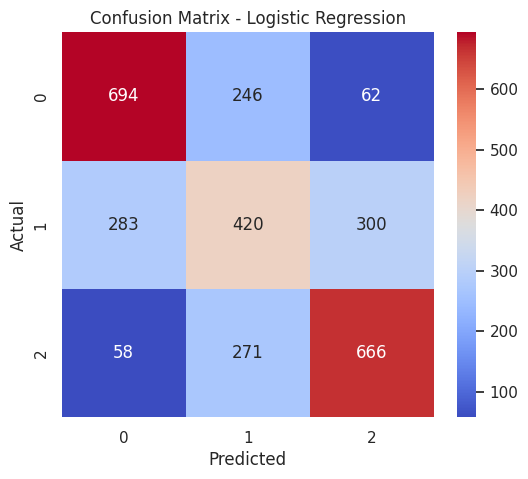


Cross Validation Scores:

[0.59833333 0.595      0.59708333 0.57791667 0.5875    ]

Average CV Accuracy:
0.5911666666666666

MODEL : Decision Tree

Accuracy  : 0.5530
Precision : 0.5622
Recall    : 0.5530
F1 Score  : 0.5567

================ CLASSIFICATION REPORT ================

              precision    recall  f1-score   support

           0       0.64      0.60      0.62      1002
           1       0.41      0.46      0.43      1003
           2       0.64      0.60      0.62       995

    accuracy                           0.55      3000
   macro avg       0.56      0.55      0.56      3000
weighted avg       0.56      0.55      0.56      3000



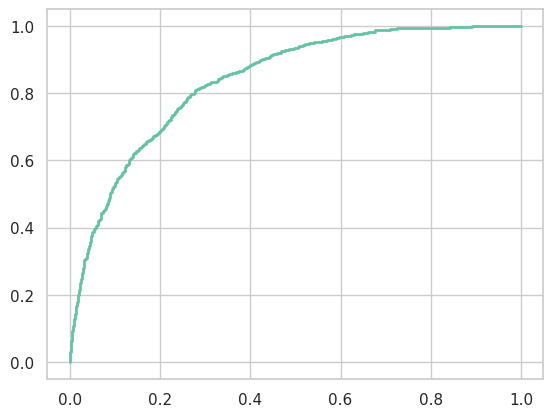

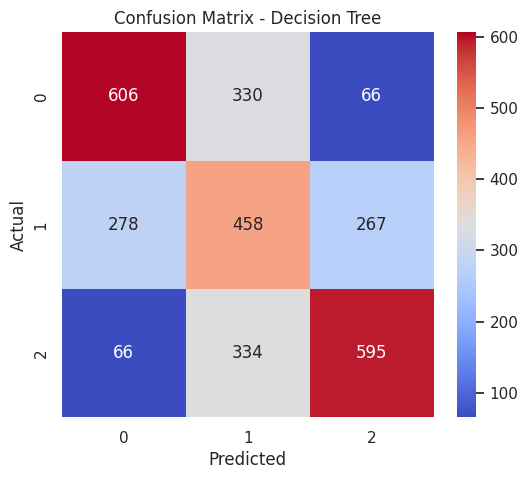


Cross Validation Scores:

[0.5475     0.54916667 0.55916667 0.53208333 0.53666667]

Average CV Accuracy:
0.5449166666666667

MODEL : Random Forest

Accuracy  : 0.5817
Precision : 0.5784
Recall    : 0.5817
F1 Score  : 0.5798

================ CLASSIFICATION REPORT ================

              precision    recall  f1-score   support

           0       0.65      0.68      0.67      1002
           1       0.44      0.42      0.43      1003
           2       0.64      0.64      0.64       995

    accuracy                           0.58      3000
   macro avg       0.58      0.58      0.58      3000
weighted avg       0.58      0.58      0.58      3000



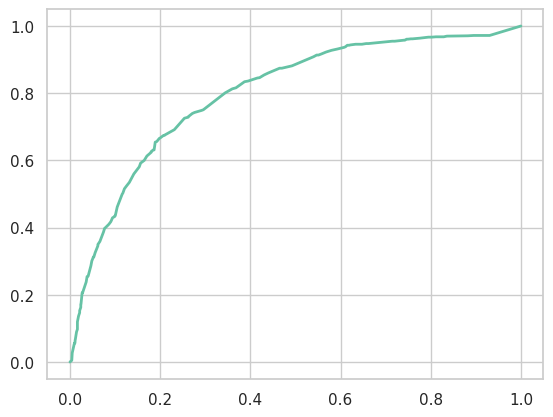

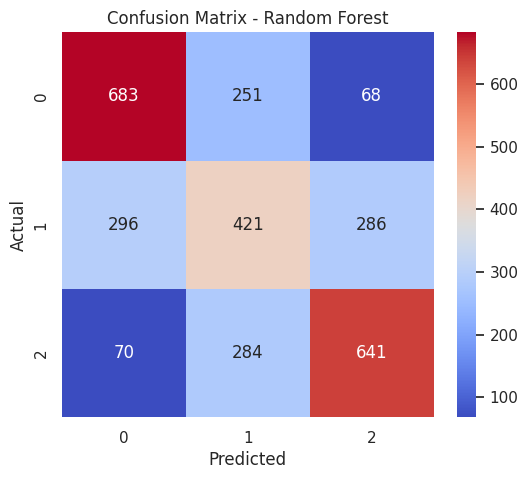


Cross Validation Scores:

[0.58041667 0.58       0.59416667 0.57041667 0.57666667]

Average CV Accuracy:
0.5803333333333333

MODEL : Gradient Boosting

Accuracy  : 0.5937
Precision : 0.5925
Recall    : 0.5937
F1 Score  : 0.5930

================ CLASSIFICATION REPORT ================

              precision    recall  f1-score   support

           0       0.66      0.69      0.68      1002
           1       0.45      0.44      0.45      1003
           2       0.67      0.65      0.66       995

    accuracy                           0.59      3000
   macro avg       0.59      0.59      0.59      3000
weighted avg       0.59      0.59      0.59      3000



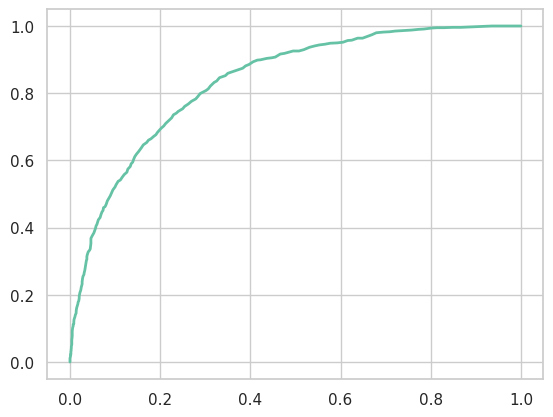

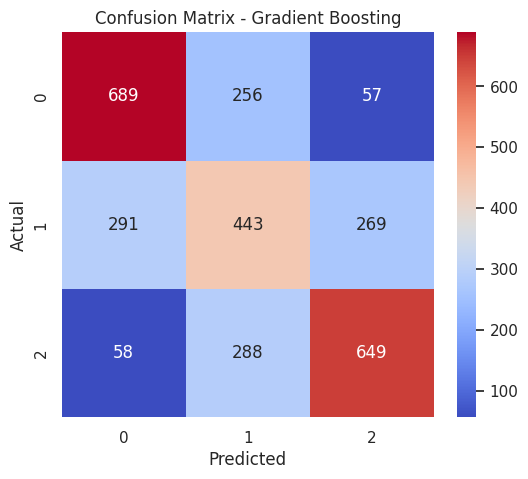


Cross Validation Scores:

[0.60041667 0.59083333 0.60375    0.57833333 0.57833333]

Average CV Accuracy:
0.5903333333333334

MODEL : KNN

Accuracy  : 0.5007
Precision : 0.5037
Recall    : 0.5007
F1 Score  : 0.4979

================ CLASSIFICATION REPORT ================

              precision    recall  f1-score   support

           0       0.53      0.65      0.58      1002
           1       0.38      0.36      0.37      1003
           2       0.61      0.49      0.54       995

    accuracy                           0.50      3000
   macro avg       0.50      0.50      0.50      3000
weighted avg       0.50      0.50      0.50      3000



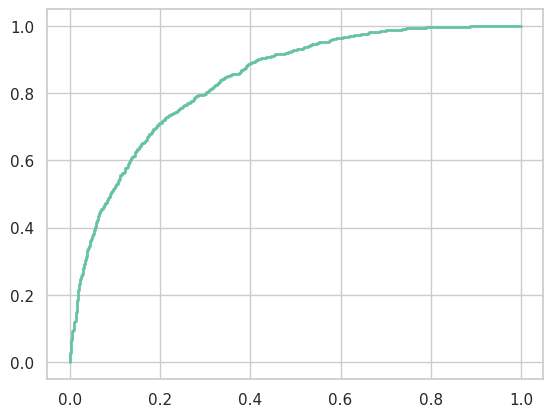

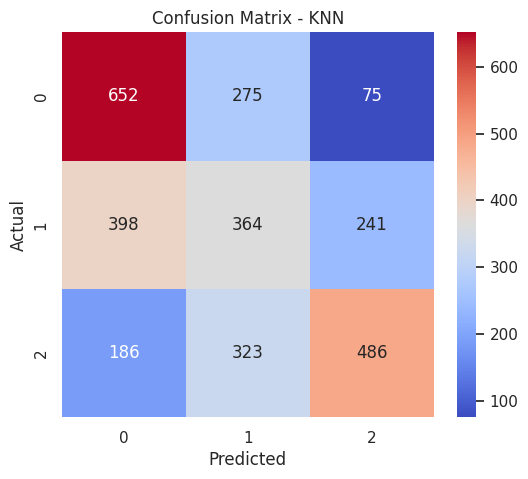


Cross Validation Scores:

[0.49958333 0.49541667 0.51041667 0.49625    0.49708333]

Average CV Accuracy:
0.49974999999999997

MODEL : SVM

Accuracy  : 0.5983
Precision : 0.5988
Recall    : 0.5983
F1 Score  : 0.5986

================ CLASSIFICATION REPORT ================

              precision    recall  f1-score   support

           0       0.68      0.68      0.68      1002
           1       0.45      0.45      0.45      1003
           2       0.66      0.66      0.66       995

    accuracy                           0.60      3000
   macro avg       0.60      0.60      0.60      3000
weighted avg       0.60      0.60      0.60      3000



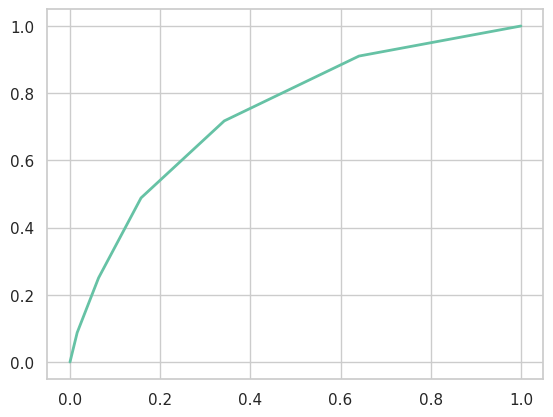

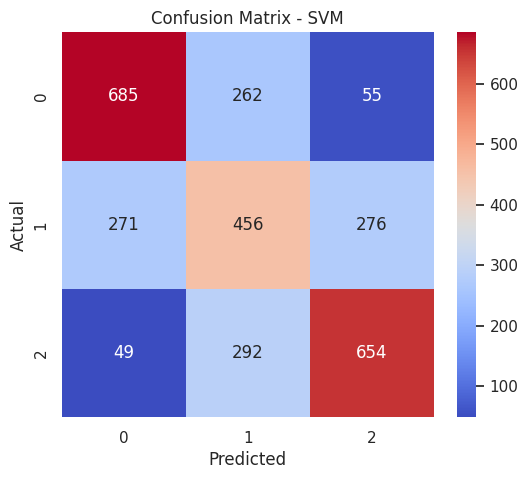


Cross Validation Scores:

[0.58875    0.59541667 0.60416667 0.57625    0.58333333]

Average CV Accuracy:
0.5895833333333333

MODEL : XGBoost

Accuracy  : 0.5663
Precision : 0.5649
Recall    : 0.5663
F1 Score  : 0.5656

================ CLASSIFICATION REPORT ================

              precision    recall  f1-score   support

           0       0.63      0.64      0.64      1002
           1       0.42      0.41      0.42      1003
           2       0.64      0.64      0.64       995

    accuracy                           0.57      3000
   macro avg       0.57      0.57      0.57      3000
weighted avg       0.56      0.57      0.57      3000



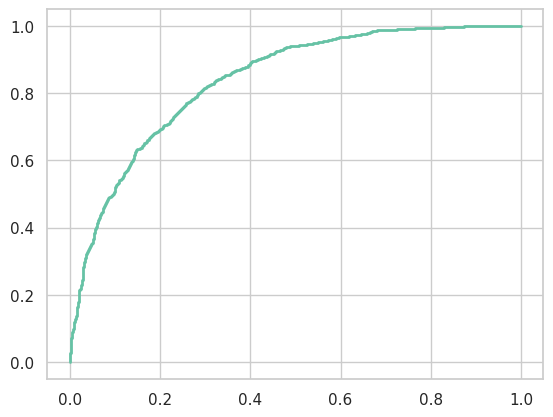

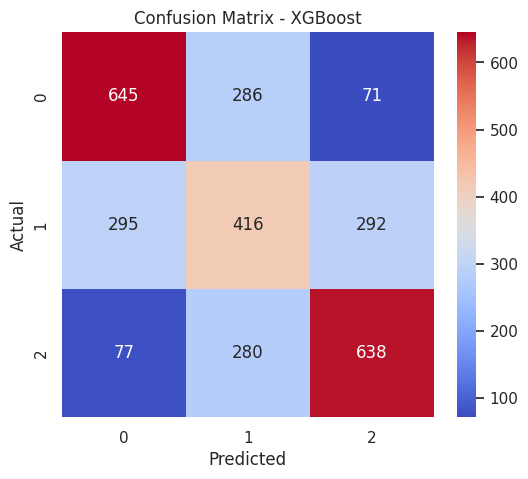


Cross Validation Scores:

[0.5725     0.57125    0.56666667 0.55666667 0.56166667]

Average CV Accuracy:
0.56575


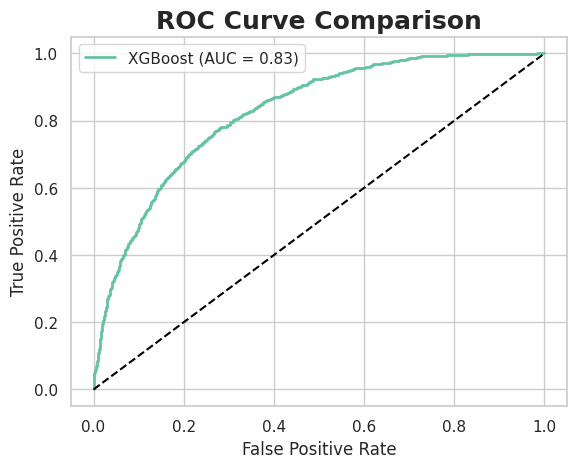


================ FINAL MODEL RESULTS ================

                 Model  Accuracy  Precision    Recall  F1 Score   ROC_AUC  \
5                  SVM  0.598333   0.598811  0.598333  0.598564  0.839550   
3    Gradient Boosting  0.593667   0.592533  0.593667  0.592997  0.839906   
0  Logistic Regression  0.593333   0.588692  0.593333  0.590727  0.840849   
2        Random Forest  0.581667   0.578365  0.581667  0.579816  0.835757   
6              XGBoost  0.566333   0.564853  0.566333  0.565564  0.827689   
1        Decision Tree  0.553000   0.562184  0.553000  0.556742  0.799062   
4                  KNN  0.500667   0.503677  0.500667  0.497873  0.741042   

   CV Accuracy  
5     0.589583  
3     0.590333  
0     0.591167  
2     0.580333  
6     0.565750  
1     0.544917  
4     0.499750  


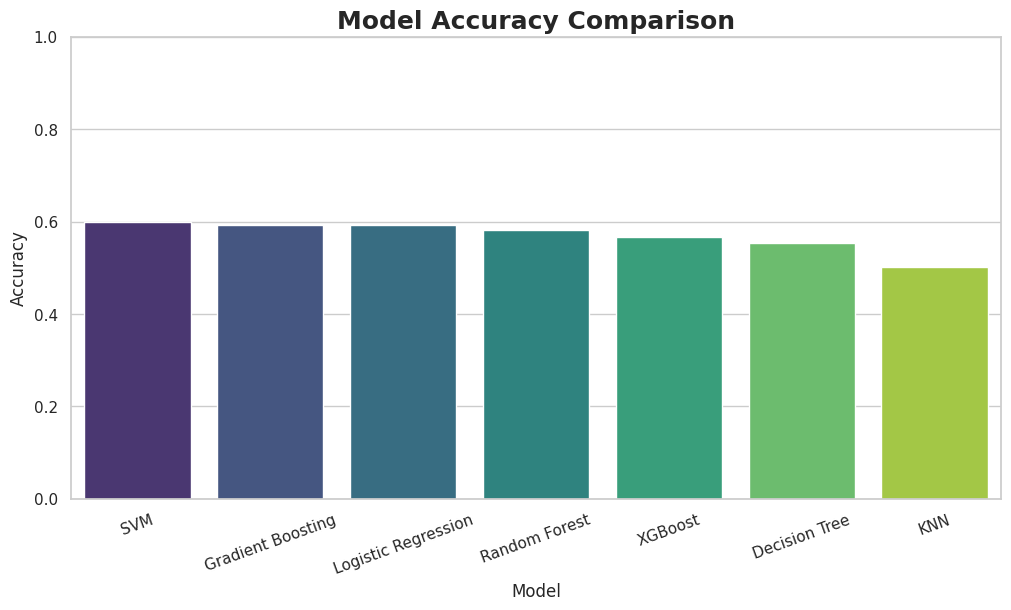


BEST MODEL : SVM

Clean dataset saved successfully!

================ PROJECT COMPLETED ================



In [16]:
df["career_readiness_class"] = pd.qcut(
    df["overall_career_readiness_score"],
    q=3,
    labels=[0, 1, 2]
)

df.drop("student_id", axis=1, inplace=True)
X = df.drop(
    [
        "overall_career_readiness_score",
        "career_readiness_class"
    ],
    axis=1
)

y = df["career_readiness_class"]

label_encoders = {}

categorical_columns = X.select_dtypes(include="object").columns

print("\n================ CATEGORICAL COLUMNS ================\n")

print(categorical_columns)

for col in categorical_columns:

    le = LabelEncoder()

    X[col] = le.fit_transform(
        X[col].astype(str)
    )

    label_encoders[col] = le

# =========================================================
# TRAIN TEST SPLIT
# IMPORTANT:
# Split BEFORE imputation to avoid data leakage
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

imputer = SimpleImputer(strategy="median")

# Fit only on training data
X_train = imputer.fit_transform(X_train)

# Transform test data
X_test = imputer.transform(X_test)

# =========================================================
# CHECK NaN AFTER IMPUTATION
# =========================================================

print("\n================ NaN CHECK AFTER IMPUTATION ================\n")

print("Train NaN Count:", np.isnan(X_train).sum())
print("Test NaN Count :", np.isnan(X_test).sum())

# =========================================================
# TRAIN TEST SHAPE
# =========================================================

print("\n================ TRAIN TEST SHAPES ================\n")

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

# =========================================================
# MODELS
# =========================================================

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "SVM": SVC(
        probability=True
    ),

    "XGBoost": XGBClassifier(
        eval_metric='mlogloss',
        random_state=42
    )
}

# =========================================================
# STORE RESULTS
# =========================================================

results = []

# =========================================================
# ROC CURVE FIGURE
# =========================================================

plt.figure(figsize=(12, 8))

# =========================================================
# TRAIN MODELS
# =========================================================

for name, model in models.items():

    print("\n================================================")
    print(f"MODEL : {name}")
    print("================================================")

    # =====================================================
    # TRAIN MODEL
    # =====================================================

    model.fit(X_train, y_train)

    # =====================================================
    # PREDICTIONS
    # =====================================================

    y_pred = model.predict(X_test)

    # =====================================================
    # PROBABILITY
    # =====================================================

    y_prob = model.predict_proba(X_test)

    # =====================================================
    # METRICS
    # =====================================================

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )

    # =====================================================
    # PRINT RESULTS
    # =====================================================

    print(f"\nAccuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    # =====================================================
    # CLASSIFICATION REPORT
    # =====================================================

    print("\n================ CLASSIFICATION REPORT ================\n")

    print(classification_report(y_test, y_pred))

    # =====================================================
    # CONFUSION MATRIX
    # =====================================================

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='coolwarm'
    )

    plt.title(f"Confusion Matrix - {name}")

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

    # =====================================================
    # ROC CURVE
    # =====================================================
    # Using class 2 as positive class
    # =====================================================

    y_test_binary = (y_test == 2).astype(int)

    y_prob_binary = y_prob[:, 2]

    fpr, tpr, thresholds = roc_curve(
        y_test_binary,
        y_prob_binary
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f'{name} (AUC = {roc_auc:.2f})'
    )

    # =====================================================
    # CROSS VALIDATION
    # =====================================================

    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='accuracy'
    )

    print("\nCross Validation Scores:\n")

    print(cv_scores)

    print("\nAverage CV Accuracy:")

    print(cv_scores.mean())

    # =====================================================
    # SAVE RESULTS
    # =====================================================

    results.append({

        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC_AUC": roc_auc,
        "CV Accuracy": cv_scores.mean()

    })

# =========================================================
# FINAL ROC CURVE
# =========================================================

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    color='black'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve Comparison",
    fontsize=18,
    fontweight='bold'
)

plt.legend()

plt.show()

# =========================================================
# RESULTS DATAFRAME
# =========================================================

results_df = pd.DataFrame(results)

# =========================================================
# SORT BY ACCURACY
# =========================================================

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

# =========================================================
# SHOW RESULTS
# =========================================================

print("\n================ FINAL MODEL RESULTS ================\n")

print(results_df)

# =========================================================
# VISUALIZE ACCURACY
# =========================================================

plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy",
    palette="viridis"
)

plt.title(
    "Model Accuracy Comparison",
    fontsize=18,
    fontweight="bold"
)

plt.xticks(rotation=20)

plt.ylim(0, 1)

plt.show()

# =========================================================
# BEST MODEL
# =========================================================

best_model_name = results_df.iloc[0]["Model"]

print("\n================================================")
print(f"BEST MODEL : {best_model_name}")
print("================================================")

# =========================================================
# FEATURE IMPORTANCE
# =========================================================

best_model = models[best_model_name]

if hasattr(best_model, "feature_importances_"):

    importance = pd.DataFrame({

        "Feature": X.columns,
        "Importance": best_model.feature_importances_

    })

    importance = importance.sort_values(
        by="Importance",
        ascending=False
    )

    print("\n================ FEATURE IMPORTANCE ================\n")

    print(importance.head(15))

    # =====================================================
    # PLOT FEATURE IMPORTANCE
    # =====================================================

    plt.figure(figsize=(12, 8))

    sns.barplot(
        data=importance.head(15),
        x="Importance",
        y="Feature",
        palette="magma"
    )

    plt.title(
        f"Top Feature Importance - {best_model_name}",
        fontsize=18,
        fontweight="bold"
    )

    plt.show()

# =========================================================
# SAVE CLEAN DATASET
# =========================================================

clean_df = pd.DataFrame(
    X_train
)

clean_df.to_csv(
    "clean_train_dataset.csv",
    index=False
)

print("\nClean dataset saved successfully!")

# =========================================================
# END
# =========================================================

print("\n================ PROJECT COMPLETED ================\n")

## Thank you........pls upvote!!!!!!!!!!!!!